## Mini-Projeto Avaliativo - Módulo 1 - Semana 07

Projeto desenvolvido para o mini-projeto do curso Análise de Dados - SCTEC.

**Aluna:** Laís Kugik Varela Alegri - Turma 05

**Objetivo:**  
Realizar uma Análise Exploratória de Dados (AED) aplicada ao varejo para aprender como transformar dados brutos em informações úteis.

### 1. Importando as bibliotecas

In [2]:
# Caso não tenha as bibliotecas instaladas execute essa célula antes da próxima!

%pip install -q pandas numpy seaborn matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Importação das bibliotecas que serão utilizadas durante o miniprojeto:

import os
import csv
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

### 2. Carregamento do dataset (base de dados)

In [1]:
# Diferente do VS Code local, o Google Colab não enxerga os arquivos desta pasta automaticamente.
# Rode essa célula para enviar o arquivo que será a nossa base de dados.
# Se estiver rodando no Google Colab, esta célula abre a janela de upload
# e organiza o arquivo na subpasta dataset/, igual à estrutura do repositório.

# Selecione o arquivo do mini projeto: Base Varejo.csv

try:
    from google.colab import files
    enviados = files.upload()
    os.makedirs("dataset", exist_ok=True)
    for nome in enviados:
        os.replace(nome, f"dataset/{nome}")
except ImportError:
    print("Rodando localmente (VS Code) — o arquivo já está em dataset/, na pasta deste projeto.")

Rodando localmente (VS Code) — o arquivo já está em dataset/, na pasta deste projeto.


### 3. Carregar a base varejo.csv com pandas e mostrar: número de registros, colunas e tipos de dados.


In [ ]:
# Carregando o arquivo varejo.csv como um DataFrame com o Pandas

vendas = pd.read_csv("dataset/Base Varejo.csv", sep=';')

# Shape exibe a quantidade de linhas e colunas
print(f"A 'Base Varejo.csv' possui {vendas.shape[0]} registros (linhas) e {vendas.shape[1]} colunas.\n")

print(f"As colunas existentes e o tipo de dados de cada uma delas pode ser verificado abaixo:")

# Dtypes exibe o nome das colunas e o tipo
display(vendas.dtypes.reset_index(name="Tipo").rename(columns={"index": "Coluna"}))


A 'Base Varejo.csv' possui 830000 registros (linhas) e 14 colunas.

As colunas existentes e o tipo de dados de cada uma delas pode ser verificado abaixo:


,Coluna,Tipo
0,DATA,str
1,CO_ID,int64
2,CL_ID,int64
3,CL_GENERO,str
4,CL_EC,int64
5,CL_FHL,int64
6,CL_SEG,str
7,PR_ID,int64
8,PR_CAT,str
9,PR_NOME,str


In [5]:
# Também é possível visualizar informações gerais do DataFrame com o .info()
display(vendas.info())

<class 'pandas.DataFrame'>
RangeIndex: 830000 entries, 0 to 829999
Data columns (total 14 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   DATA         830000 non-null  str    
 1   CO_ID        830000 non-null  int64  
 2   CL_ID        830000 non-null  int64  
 3   CL_GENERO    830000 non-null  str    
 4   CL_EC        830000 non-null  int64  
 5   CL_FHL       830000 non-null  int64  
 6   CL_SEG       830000 non-null  str    
 7   PR_ID        830000 non-null  int64  
 8   PR_CAT       830000 non-null  str    
 9   PR_NOME      830000 non-null  str    
 10  Unnamed: 10  0 non-null       float64
 11  Unnamed: 11  0 non-null       float64
 12  Unnamed: 12  0 non-null       float64
 13  Unnamed: 13  0 non-null       float64
dtypes: float64(4), int64(5), str(5)
memory usage: 88.7 MB


None

In [7]:
# Outra forma de ler o arquivo, é utilizando a biblioteca nativa do python usando o csv.DictReader:

with open("dataset/varejo.csv", encoding="utf-8") as arquivo:
    todas_vendas = list(csv.DictReader(arquivo, delimiter=";"))

# Exibe o primeiro registro da tabela:
display(todas_vendas[0])

{'DATA': '01/02/2019',
 'CO_ID': '1000',
 'CL_ID': '534',
 'CL_GENERO': 'M',
 'CL_EC': '4',
 'CL_FHL': '1',
 'CL_SEG': 'C',
 'PR_ID': '67',
 'PR_CAT': 'BEBIDAS',
 'PR_NOME': 'REFRIGERANTE GUARANA',
 '': ''}

### 4. Verificar e reportar ao menos dois problemas básicos: 
- Fazer as três etapas de limpeza mínima necessária: 
  - remover ou imputar nulos (explique a escolha), 
  - eliminar duplicatas relevantes e 
  - ajustar tipos de dados (ex.: converter coluna DATA para datetime).


#### 4.1 Valores nulos por coluna

In [19]:
# A função .isna().sum() vai calcular a quantidade de valores ausentes por coluna
display(vendas.isna().sum()) 

# Foi possível identificar que não existem valores ausentes nas colunas que possuem nome.
# Existem 4 colunas "Unnamed" (sem nome) e com valores vazios em todas as linhas, vou removê-las pois não terão relevância nas análises.
# Removendo as COLUNAS que possuem TODAS as linhas vazias:

vendas_limpo = vendas.dropna(axis=1, how="all")     
  
print("Quantidade de valores ausentes (NaN):")  
display(vendas_limpo.isna().sum())

print(f"Quantidade de linhas e colunas depois da limpeza das colunas vazias: {vendas_limpo.shape}")


# Verificando se existem valores ausentes após a limpeza:
linhas_nan = vendas_limpo.isna().any(axis=1).sum()

if linhas_nan > 0:
    print(f"O DataFrame possui {linhas_nan} linhas com valores ausentes.")
else:
    print("O DataFrame não possui valores ausentes.")




DATA                0
CO_ID               0
CL_ID               0
CL_GENERO           0
CL_EC               0
CL_FHL              0
CL_SEG              0
PR_ID               0
PR_CAT              0
PR_NOME             0
Unnamed: 10    830000
Unnamed: 11    830000
Unnamed: 12    830000
Unnamed: 13    830000
dtype: int64

Quantidade de valores ausentes (NaN):


DATA         0
CO_ID        0
CL_ID        0
CL_GENERO    0
CL_EC        0
CL_FHL       0
CL_SEG       0
PR_ID        0
PR_CAT       0
PR_NOME      0
dtype: int64

Quantidade de linhas e colunas depois da limpeza das colunas vazias: (830000, 10)
O DataFrame não possui valores ausentes.


In [34]:
# Identifiquei que existiam registros com o valor "#N/D"

# Verificando quantas células aparecem com o valor "#N/D"
print("Quantidade de #N/D:")
display((vendas_limpo == "#N/D").sum())

linhas_nd = vendas_limpo[vendas_limpo.eq("#N/D").any(axis=1)]

# Exibindo as colunas que possuem linhas com "#N/D"
display(linhas_nd)

# Pedindo para agrupar os "#N/D" por código do produto ("PR_ID")

produtos_nd = (
    vendas_limpo[(vendas_limpo["PR_CAT"] == "#N/D") | (vendas_limpo["PR_NOME"] == "#N/D")]
    .groupby("PR_ID")
    .size()
    .reset_index(name="qtd_nd")
    .sort_values("qtd_nd", ascending=False)
)

display(produtos_nd)
## Com essa análise foi possível verificar que apenas o produto com o ID igual a 107 está sem Categoria e Nome.
## Poderia ser verificado em algum cadastro, qual é o nome e categoria desse produto específico, e depois ajustar com um "replace" no DataFrame.



# Decidi manter as linhas que possuem "#N/D" na coluna CATEGORIA e PRODUTO, pois elas possuem informações nas demais colunas como:
# DATA, NOTA FISCAL, ID DO CLIENTE, SEXO, CLASSE ECONOMICA, QUANTIDADE DE FILHOS, ID DO PRODUTO.
# E essas informações são relevantes dependendo da análise desejada.

Quantidade de #N/D:


DATA            0
CO_ID           0
CL_ID           0
CL_GENERO       0
CL_EC           0
CL_FHL          0
CL_SEG          0
PR_ID           0
PR_CAT       3650
PR_NOME      3650
dtype: int64

,DATA,CO_ID,CL_ID,CL_GENERO,CL_EC,CL_FHL,CL_SEG,PR_ID,PR_CAT,PR_NOME
82,01/02/2019,1078,290,F,1,0,B,107,#N/D,#N/D
223,01/02/2019,1103,957,M,2,3,B,107,#N/D,#N/D
640,01/02/2019,1482,453,F,1,0,B,107,#N/D,#N/D
857,01/02/2019,1683,438,F,1,0,B,107,#N/D,#N/D
917,01/02/2019,1793,608,F,3,0,C,107,#N/D,#N/D
...,...,...,...,...,...,...,...,...,...,...
829528,19/08/2022,919578,567,F,1,0,C,107,#N/D,#N/D
829602,19/08/2022,919626,758,F,3,0,B,107,#N/D,#N/D
829787,19/08/2022,919716,801,M,1,4,B,107,#N/D,#N/D
829829,19/08/2022,919716,801,M,1,4,B,107,#N/D,#N/D


,PR_ID,qtd_nd
0,107,3650


#### 4.2 Duplicatas



In [35]:
# Verifica se existem linhas duplicadas
print(f"Existem {vendas_limpo.duplicated().sum()} linhas duplicadas.")

# Remove as linhas duplicadas
vendas_limpo_sem_duplicatas = vendas_limpo.drop_duplicates()

# Quantidade de linhas e colunas após a remoção:
print(f"Quantidade de linhas e colunas após a remoção das duplicadas: {vendas_limpo_sem_duplicatas.shape}")

Existem 96553 linhas duplicadas.
Quantidade de linhas e colunas após a remoção das duplicadas: (733447, 10)


#### 4.3 E possíveis inconsistências (ex.: datas inválidas ou categorias vazias)

In [36]:

# Anteriormente com o .info() foi possível identificar que a coluna DATA está com o tipo 'str' (string)

# Visualizar as primeiras linhas do DataFrame
display(vendas_limpo_sem_duplicatas.head())

# Visualizar as últimas linhas do DataFrame
display(vendas_limpo_sem_duplicatas.tail())


# Consultando os primeiros e últimos registros, foi possível identificar que a coluna DATA está no formato DD/MM/YYYY
# Alterando o tipo da coluna DATA para datetime

vendas_limpo_sem_duplicatas["DATA"] = pd.to_datetime(vendas_limpo_sem_duplicatas["DATA"], format="%d/%m/%Y")
display(vendas_limpo_sem_duplicatas.info())

# Não encontrei outras inconsistências.


,DATA,CO_ID,CL_ID,CL_GENERO,CL_EC,CL_FHL,CL_SEG,PR_ID,PR_CAT,PR_NOME
0,01/02/2019,1000,534,M,4,1,C,67,BEBIDAS,REFRIGERANTE GUARANA
1,01/02/2019,1000,534,M,4,1,C,70,BEBIDAS,REFRIGERANTE OUTROS
2,01/02/2019,1000,534,M,4,1,C,178,HIGIENE,LENCO UMEDECIDO
3,01/02/2019,1000,534,M,4,1,C,4,ALIMENTOS,ABACAXI
4,01/02/2019,1000,534,M,4,1,C,175,LIMPEZA,LIMPADOR MULTIUSO


,DATA,CO_ID,CL_ID,CL_GENERO,CL_EC,CL_FHL,CL_SEG,PR_ID,PR_CAT,PR_NOME
829991,19/08/2022,919822,155,F,2,0,B,86,HIGIENE,PRESERVATIVO
829993,19/08/2022,919822,155,F,2,0,B,62,ALIMENTOS,SNACKS
829994,19/08/2022,919822,155,F,2,0,B,11,ALIMENTOS,AZEITE
829998,19/08/2022,919822,155,F,2,0,B,214,ALIMENTOS,CEBOLA
829999,19/08/2022,919822,155,F,2,0,B,59,ALIMENTOS,SALGADINHO


<class 'pandas.DataFrame'>
Index: 733447 entries, 0 to 829999
Data columns (total 10 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   DATA       733447 non-null  datetime64[us]
 1   CO_ID      733447 non-null  int64         
 2   CL_ID      733447 non-null  int64         
 3   CL_GENERO  733447 non-null  str           
 4   CL_EC      733447 non-null  int64         
 5   CL_FHL     733447 non-null  int64         
 6   CL_SEG     733447 non-null  str           
 7   PR_ID      733447 non-null  int64         
 8   PR_CAT     733447 non-null  str           
 9   PR_NOME    733447 non-null  str           
dtypes: datetime64[us](1), int64(5), str(4)
memory usage: 61.6 MB


None

#### 4.4 Renomeando colunas para facilitar o entendimento

In [62]:
# Segundo a documentação do Kaggle as colunas significam:

# DATA: Data da compra;
# CO_ID: Identificação do número de compra (número da nota fiscal);
# CL_ID: Identificação do cliente (número do cliente);
# CL_GENERO: Sexo biológico informado pelo cliente;
# CL_EC: Estado civil do cliente: 1: Casado ou união estável; 2: Divorciado; 3: Separado; 4. Solteiro; 5: Viúvo.
# CL_FHL: Número de filhos do cliente;
# CL_SEG: Segmentação econômica do cliente (classe A, B ou C);
# PR_ID: Código do produto (SKU) adquirido;
# PR_CAT: Categoria do produto adquirido;
# PR_NOME: Nome do produto adquirido.


# Renomeando as colunas:
vendas_renomeado = vendas_limpo_sem_duplicatas.rename(columns={
    "DATA": "data_compra",
    "CO_ID": "nota_fiscal",
    "CL_ID": "cod_cliente",
    "CL_GENERO": "sexo",
    "CL_EC": "estado_civil",
    "CL_FHL": "qtd_filhos",
    "CL_SEG": "classe_economica",
    "PR_ID": "cod_produto",
    "PR_CAT": "categoria",
    "PR_NOME": "produto"
})

display(vendas_renomeado.head())


,data_compra,nota_fiscal,cod_cliente,sexo,estado_civil,qtd_filhos,classe_economica,cod_produto,categoria,produto
0,2019-02-01,1000,534,M,4,1,C,67,BEBIDAS,REFRIGERANTE GUARANA
1,2019-02-01,1000,534,M,4,1,C,70,BEBIDAS,REFRIGERANTE OUTROS
2,2019-02-01,1000,534,M,4,1,C,178,HIGIENE,LENCO UMEDECIDO
3,2019-02-01,1000,534,M,4,1,C,4,ALIMENTOS,ABACAXI
4,2019-02-01,1000,534,M,4,1,C,175,LIMPEZA,LIMPADOR MULTIUSO


### 5. Gerar estatísticas descritivas básicas para coluna de número de filhos do cliente 

(média; mediana; desvio padrão; moda; máximo; mínimo; e contagem, quartis)

In [38]:
## Usando a função .describe() podemos visualizar quase todas as estatísticas descritivas da coluna número de filhos do cliente.
## A moda é a única que será calculada separadamente.

estatisticas = vendas_renomeado["qtd_filhos"].describe()

#display(estatisticas)

print("As informações estatísticas descritivas básicas para a coluna número de filhos por cliente são:\n")

print(f" - Média: {estatisticas['mean']:.2f}.")
print(f" - Mediana: {estatisticas['50%']:.2f}.")
print(f" - Desvio Padrão: {estatisticas['std']:.2f}.")
print(f" - Máximo: {estatisticas['max']:.0f}.")
print(f" - Mínimo: {estatisticas['min']:.0f}.")
print(f" - Contagem: {estatisticas['count']:.0f}.")

print(
    f" - Quartis:\n"
    f"     25% -> {estatisticas['25%']:.0f}\n"
    f"     50% -> {estatisticas['50%']:.0f}\n"
    f"     75% -> {estatisticas['75%']:.0f}."
)

moda = vendas_renomeado["qtd_filhos"].mode().iloc[0]
print(f" - Moda: {moda}.")

As informações estatísticas descritivas básicas para a coluna número de filhos por cliente são:

 - Média: 1.15.
 - Mediana: 0.00.
 - Desvio Padrão: 1.42.
 - Máximo: 4.
 - Mínimo: 0.
 - Contagem: 733447.
 - Quartis:
     25% -> 0
     50% -> 0
     75% -> 2.
 - Moda: 0.


### 6. Explorar padrões de agrupamento com pelo menos dois agrupamentos 

(por exemplo: gênero com mais vendas, compras), usando groupby() ou pivot_table().

#### 6.1 Quantidade de vendas por categoria × classe econômica

Quais categorias são mais compradas por cada classe econômica?

,categoria,total_vendas
2,ALIMENTOS,384197
4,HIGIENE,137702
5,LIMPEZA,128632
3,BEBIDAS,38264
6,PET,28553
1,ACESSORIOS,12871
0,#N/D,3228


,categoria,classe_economica,qtd_vendas
7,ALIMENTOS,B,245501
8,ALIMENTOS,C,107578
13,HIGIENE,B,87943
16,LIMPEZA,B,82063
14,HIGIENE,C,38433
17,LIMPEZA,C,36109
6,ALIMENTOS,A,31118
10,BEBIDAS,B,24363
19,PET,B,18406
12,HIGIENE,A,11326


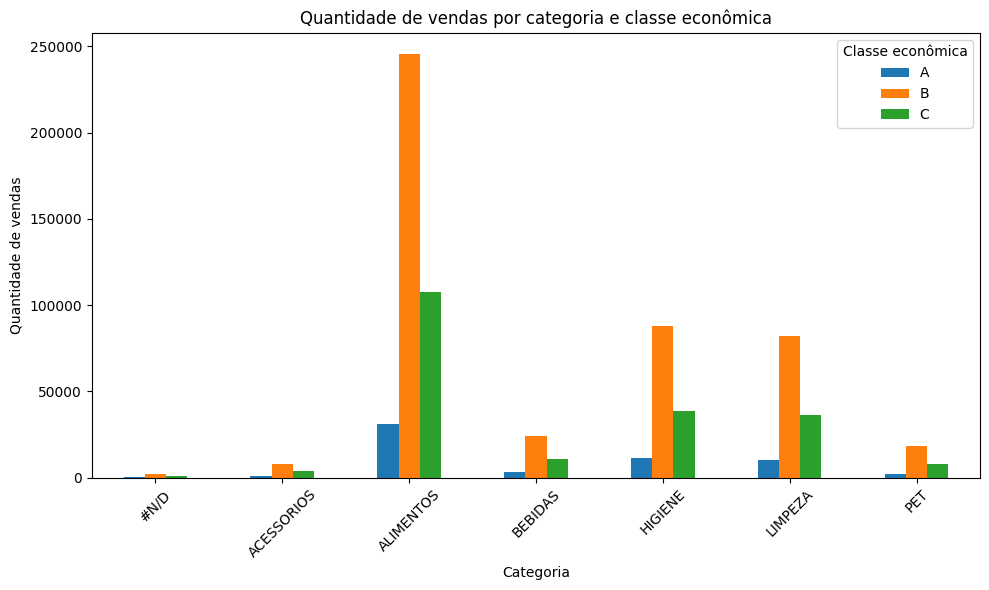

In [67]:
vendas_categoria = (
    vendas_renomeado
    .groupby(["categoria"])
    .size()
    .reset_index(name="total_vendas")
    .sort_values("total_vendas", ascending=False)
)

display(vendas_categoria)

vendas_categoria_classe = (
    vendas_renomeado
    .groupby(["categoria", "classe_economica"])
    .size()
    .reset_index(name="qtd_vendas")
    .sort_values("qtd_vendas", ascending=False)
)

display(vendas_categoria_classe)

# Gráfico

grafico = vendas_categoria_classe.pivot(
    index="categoria",
    columns="classe_economica",
    values="qtd_vendas"
)

grafico.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Quantidade de vendas por categoria e classe econômica")
plt.xlabel("Categoria")
plt.ylabel("Quantidade de vendas")
plt.xticks(rotation=45)
plt.legend(title="Classe econômica")
plt.tight_layout()
plt.show()

#### 6.2 Produtos mais vendidos × classe econômica

Quais são os produtos mais comprados por cada classe econômica?

In [58]:
produtos_classe = (
    vendas_renomeado
    .groupby(["produto", "classe_economica"])
    .size()
    .reset_index(name="qtd_vendas")
    .sort_values(by="qtd_vendas", ascending=False)
)
#print(produtos_classe)


# Top 5 produtos mais vendidos por Classe econômica

top_5_A = produtos_classe[
    produtos_classe["classe_economica"] == "A"
].head(5)

top_5_B = produtos_classe[
    produtos_classe["classe_economica"] == "B"
].head(5)

top_5_C = produtos_classe[
    produtos_classe["classe_economica"] == "C"
].head(5)

display(top_5_A)
display(top_5_B)
display(top_5_C)


,produto,classe_economica,qtd_vendas
255,PRESUNTO COZIDO,A,1052
144,GEL,A,577
156,HIDRATANTE,A,566
291,REFRIGERANTE OUTROS,A,561
183,LIMAO,A,558


,produto,classe_economica,qtd_vendas
256,PRESUNTO COZIDO,B,8093
244,PAPINHA INFANTIL,B,4240
325,SARDINHA,B,4211
241,PAPEL HIGIENICO,B,4211
73,CEBOLA,B,4191


,produto,classe_economica,qtd_vendas
257,PRESUNTO COZIDO,C,3574
326,SARDINHA,C,1872
86,CHUPETA,C,1872
149,GRANOLA,C,1871
296,REMOVEDOR,C,1862


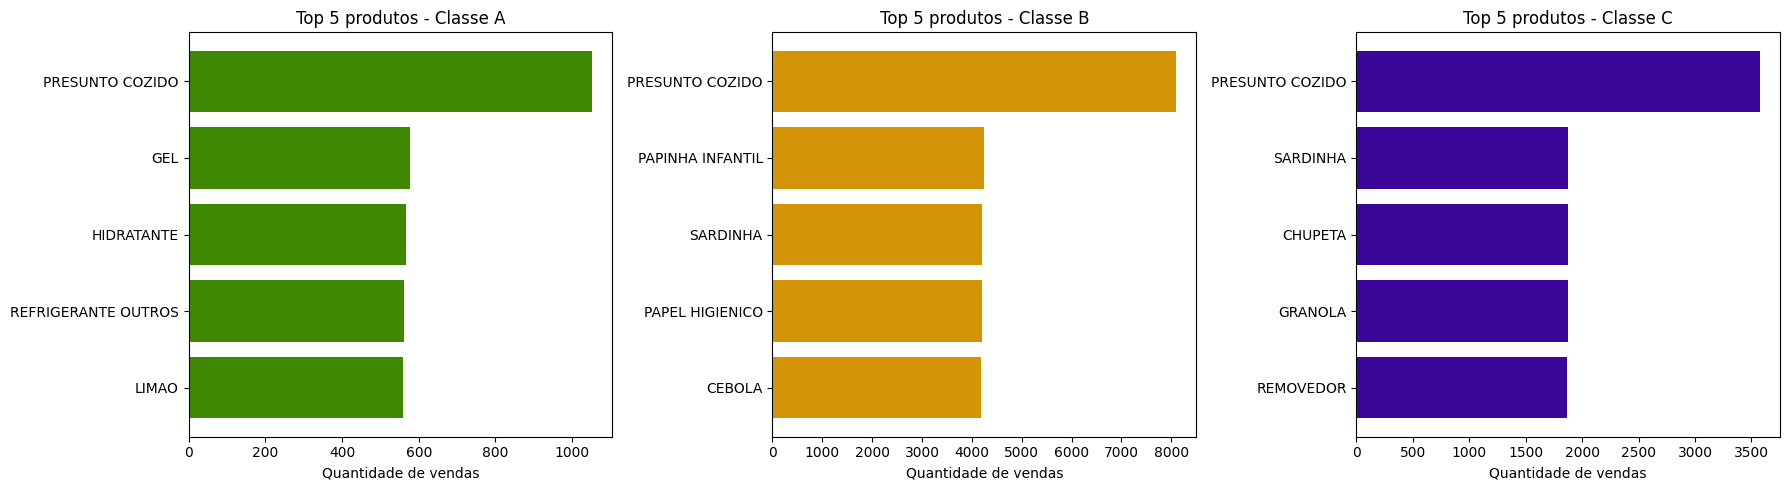

In [59]:
# Gráficos

fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# Classe A
top_5_A = top_5_A.sort_values("qtd_vendas", ascending=True)
axs[0].barh(
    top_5_A["produto"],
    top_5_A["qtd_vendas"],
    color="#3F8804"
)
axs[0].set_title("Top 5 produtos - Classe A")
axs[0].set_xlabel("Quantidade de vendas")

# Classe B
top_5_B = top_5_B.sort_values("qtd_vendas", ascending=True)
axs[1].barh(
    top_5_B["produto"],
    top_5_B["qtd_vendas"],
    color="#D49408"
)
axs[1].set_title("Top 5 produtos - Classe B")
axs[1].set_xlabel("Quantidade de vendas")

# Classe C
top_5_C = top_5_C.sort_values("qtd_vendas", ascending=True)
axs[2].barh(
    top_5_C["produto"],
    top_5_C["qtd_vendas"],
    color="#3B079B"
)
axs[2].set_title("Top 5 produtos - Classe C")
axs[2].set_xlabel("Quantidade de vendas")

plt.tight_layout()
plt.show()

#### 6.3 Sexo × Classe econômica — quantidade de vendas

Qual combinação de sexo e classe econômica concentra mais vendas?

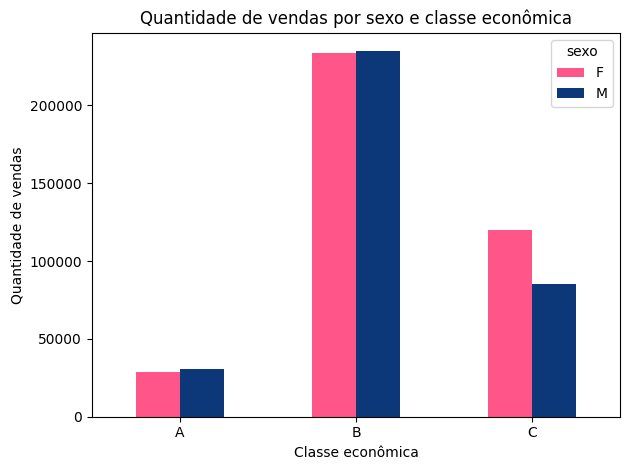

In [64]:
vendas_sexo_classe = (
    vendas_renomeado
    .groupby(["sexo", "classe_economica"])
    .size()
    .reset_index(name="qtd_vendas")
    .sort_values("qtd_vendas", ascending=False)
)

# Gráfico
vendas_sexo_classe.pivot(
    index="classe_economica",
    columns="sexo",
    values="qtd_vendas"
).plot(kind="bar", color=["#FF5588", "#0C3779"])

plt.title("Quantidade de vendas por sexo e classe econômica")
plt.xlabel("Classe econômica")
plt.ylabel("Quantidade de vendas")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Produzir um pequeno bloco de conclusões (3–6 tópicos) com os principais insights obtidos e possíveis problemas remanescentes na base. Notebook Python, MD ou um “print”.